In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, r2_score

import pickle

In [31]:
df = pd.read_csv(r"D:\Projects\DataScience\PersonalityIdentifier\data-final.csv", sep="\t")
df.head()

,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,EST1,EST2,EST3,EST4,EST5,EST6,EST7,EST8,EST9,EST10,AGR1,AGR2,AGR3,AGR4,AGR5,AGR6,AGR7,AGR8,AGR9,AGR10,CSN1,CSN2,CSN3,CSN4,CSN5,CSN6,CSN7,CSN8,CSN9,CSN10,...,AGR1_E,AGR2_E,AGR3_E,AGR4_E,AGR5_E,AGR6_E,AGR7_E,AGR8_E,AGR9_E,AGR10_E,CSN1_E,CSN2_E,CSN3_E,CSN4_E,CSN5_E,CSN6_E,CSN7_E,CSN8_E,CSN9_E,CSN10_E,OPN1_E,OPN2_E,OPN3_E,OPN4_E,OPN5_E,OPN6_E,OPN7_E,OPN8_E,OPN9_E,OPN10_E,dateload,screenw,screenh,introelapse,testelapse,endelapse,IPC,country,lat_appx_lots_of_err,long_appx_lots_of_err
0,4.0,1.0,5.0,2.0,5.0,1.0,5.0,2.0,4.0,1.0,1.0,4.0,4.0,2.0,2.0,2.0,2.0,2.0,3.0,2.0,2.0,5.0,2.0,4.0,2.0,3.0,2.0,4.0,3.0,4.0,3.0,4.0,3.0,2.0,2.0,4.0,4.0,2.0,4.0,4.0,...,4750.0,5475.0,11641.0,3115.0,3207.0,3260.0,10235.0,5897.0,1758.0,3081.0,6602.0,5457.0,1569.0,2129.0,3762.0,4420.0,9382.0,5286.0,4983.0,6339.0,3146.0,4067.0,2959.0,3411.0,2170.0,4920.0,4436.0,3116.0,2992.0,4354.0,2016-03-03 02:01:01,768.0,1024.0,9.0,234.0,6,1,GB,51.5448,0.1991
1,3.0,5.0,3.0,4.0,3.0,3.0,2.0,5.0,1.0,5.0,2.0,3.0,4.0,1.0,3.0,1.0,2.0,1.0,3.0,1.0,1.0,4.0,1.0,5.0,1.0,5.0,3.0,4.0,5.0,3.0,3.0,2.0,5.0,3.0,3.0,1.0,3.0,3.0,5.0,3.0,...,2158.0,2090.0,2143.0,2807.0,3422.0,5324.0,4494.0,3627.0,1850.0,1747.0,5163.0,5240.0,7208.0,2783.0,4103.0,3431.0,3347.0,2399.0,3360.0,5595.0,2624.0,4985.0,1684.0,3026.0,4742.0,3336.0,2718.0,3374.0,3096.0,3019.0,2016-03-03 02:01:20,1360.0,768.0,12.0,179.0,11,1,MY,3.1698,101.706
2,2.0,3.0,4.0,4.0,3.0,2.0,1.0,3.0,2.0,5.0,4.0,4.0,4.0,2.0,2.0,2.0,2.0,2.0,1.0,3.0,1.0,4.0,1.0,4.0,2.0,4.0,1.0,4.0,4.0,3.0,4.0,2.0,2.0,2.0,3.0,3.0,4.0,2.0,4.0,2.0,...,1089.0,2203.0,3386.0,1464.0,2562.0,1493.0,3067.0,13719.0,3892.0,4100.0,4286.0,4775.0,2713.0,2813.0,4237.0,6308.0,2690.0,1516.0,2379.0,2983.0,1930.0,1470.0,1644.0,1683.0,2229.0,8114.0,2043.0,6295.0,1585.0,2529.0,2016-03-03 02:01:56,1366.0,768.0,3.0,186.0,7,1,GB,54.9119,-1.3833
3,2.0,2.0,2.0,3.0,4.0,2.0,2.0,4.0,1.0,4.0,3.0,3.0,3.0,2.0,3.0,2.0,2.0,2.0,4.0,3.0,2.0,4.0,3.0,4.0,2.0,4.0,2.0,4.0,3.0,4.0,2.0,4.0,4.0,4.0,1.0,2.0,2.0,3.0,1.0,4.0,...,6062.0,11952.0,1040.0,2264.0,3664.0,3049.0,4912.0,7545.0,4632.0,6896.0,2824.0,520.0,2368.0,3225.0,2848.0,6264.0,3760.0,10472.0,3192.0,7704.0,3456.0,6665.0,1977.0,3728.0,4128.0,3776.0,2984.0,4192.0,3480.0,3257.0,2016-03-03 02:02:02,1920.0,1200.0,186.0,219.0,7,1,GB,51.75,-1.25
4,3.0,3.0,3.0,3.0,5.0,3.0,3.0,5.0,3.0,4.0,1.0,5.0,5.0,3.0,1.0,1.0,1.0,1.0,3.0,2.0,1.0,5.0,1.0,5.0,1.0,3.0,1.0,5.0,5.0,3.0,5.0,1.0,5.0,1.0,3.0,1.0,5.0,1.0,5.0,5.0,...,6771.0,2819.0,3682.0,2511.0,16204.0,1736.0,28983.0,1612.0,2437.0,4532.0,3843.0,7019.0,3102.0,3153.0,2869.0,6550.0,1811.0,3682.0,21500.0,20587.0,8458.0,3510.0,17042.0,7029.0,2327.0,5835.0,6846.0,5320.0,11401.0,8642.0,2016-03-03 02:02:57,1366.0,768.0,8.0,315.0,17,2,KE,1.0,38.0


In [14]:
df.shape

(1015341, 110)

In [15]:
df.columns

Index(['EXT1', 'EXT2', 'EXT3', 'EXT4', 'EXT5', 'EXT6', 'EXT7', 'EXT8', 'EXT9',
       'EXT10',
       ...
       'dateload', 'screenw', 'screenh', 'introelapse', 'testelapse',
       'endelapse', 'IPC', 'country', 'lat_appx_lots_of_err',
       'long_appx_lots_of_err'],
      dtype='str', length=110)

In [32]:
df.columns = df.columns.str.lower()
df = df.dropna()

In [33]:
reverse_cols = [
    'ext2','ext4','ext6','ext8','ext10',
    'agr2','agr4','agr6','agr8','agr10',
    'csn2','csn4','csn6','csn8','csn10',
    'est2','est4','est6','est8','est10',
    'opn2','opn4','opn6','opn8','opn10'
]

for col in reverse_cols:
    df[col] = 6 - df[col]

In [34]:
df['extraversion'] = df[[f'ext{i}' for i in range(1,11)]].mean(axis=1)
df['neuroticism'] = df[[f'est{i}' for i in range(1,11)]].mean(axis=1)
df['agreeableness'] = df[[f'agr{i}' for i in range(1,11)]].mean(axis=1)
df['conscientiousness'] = df[[f'csn{i}' for i in range(1,11)]].mean(axis=1)
df['openness'] = df[[f'opn{i}' for i in range(1,11)]].mean(axis=1)

C:\Users\ishit\AppData\Local\Temp\ipykernel_9556\2522774359.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['extraversion'] = df[[f'ext{i}' for i in range(1,11)]].mean(axis=1)
C:\Users\ishit\AppData\Local\Temp\ipykernel_9556\2522774359.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['neuroticism'] = df[[f'est{i}' for i in range(1,11)]].mean(axis=1)
C:\Users\ishit\AppData\Local\Temp\ipykernel_9556\2522774359.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.inser

In [52]:
X = df[
    [f'est{i}' for i in range(1,11)] +
    [f'agr{i}' for i in range(1,11)] +
    [f'csn{i}' for i in range(1,11)] +
    [f'opn{i}' for i in range(1,11)]
]

y = df['extraversion']

In [53]:
df_sample = df.sample(n=50000, random_state=42)

X = df_sample[feature_cols]
y = df_sample['extraversion']

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [56]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression
RMSE: 2.228199941930413e-14
R2 Score: 1.0


In [57]:
df_sample = df.sample(n=50000, random_state=42)

X_sample = df_sample[['agreeableness','conscientiousness','neuroticism','openness']]
y_sample = df_sample['extraversion']

X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.2
)

rf = RandomForestRegressor(n_estimators=50, max_depth=10)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\nRandom Forest")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))


Random Forest
RMSE: 0.8614249704662347
R2 Score: 0.09432398177665147


In [58]:
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("Gradient Boosting Regression")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))
print("R2 Score:", r2_score(y_test, y_pred_gb))

Gradient Boosting Regression
RMSE: 0.8578898524997778
R2 Score: 0.10174216016579629


In [60]:
traits = {
    'extraversion': 'ext',
    'agreeableness': 'agr',
    'conscientiousness': 'csn',
    'neuroticism': 'est',
    'openness': 'opn'
}

models = {}

for trait, prefix in traits.items():

    # Remove same trait questions
    X = df_sample[
        [col for col in df_sample.columns 
         if col.startswith(('ext','agr','csn','est','opn')) 
         and not col.startswith(prefix)]
    ]

    y = df_sample[trait]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    model = GradientBoostingRegressor(n_estimators=100, max_depth=3)
    model.fit(X_train, y_train)

    models[trait] = model

    y_pred = model.predict(X_test)
    print(f"{trait} R2:", r2_score(y_test, y_pred))

extraversion R2: 0.37389987848829376
agreeableness R2: 0.2985978188616597
conscientiousness R2: 0.18395578107605692
neuroticism R2: 0.17288942054256273
openness R2: 0.2124575162221518


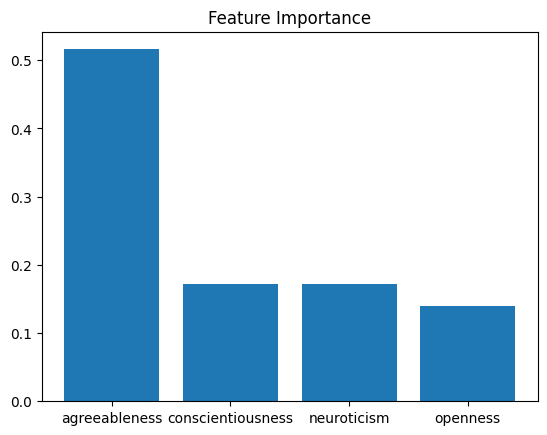

In [61]:
import matplotlib.pyplot as plt

importance = rf.feature_importances_
features = X_sample.columns

plt.bar(features, importance)
plt.title("Feature Importance")
plt.show()

In [63]:
for trait, model in models.items():
    with open(f"{trait}_model.pkl", "wb") as f:
        pickle.dump(model, f)

In [64]:
feature_cols_map = {}

for trait, prefix in traits.items():
    feature_cols = [
        col for col in df_sample.columns
        if col.startswith(('ext','agr','csn','est','opn'))
        and not col.startswith(prefix)
    ]
    feature_cols_map[trait] = feature_cols

In [65]:
with open("feature_cols.pkl", "wb") as f:
    pickle.dump(feature_cols_map, f)